In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from  sklearn.model_selection import train_test_split
from  sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error,r2_score


In [2]:
df=pd.read_csv('Position_Salaries.csv')
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [3]:
correlation=df['Level'].corr(df['Salary'])
correlation

np.float64(0.8179494074776199)

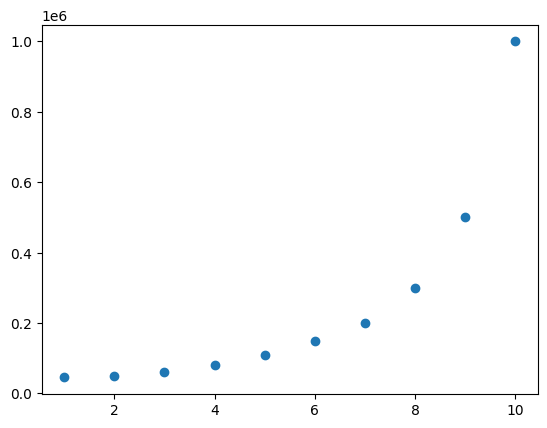

In [4]:
plt.scatter(df['Level'],df['Salary'] )

In [5]:
x=df[['Level']]
y=df['Salary']

In [6]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)
train_test_split(x,y,train_size=0.8,random_state=42)

[   Level
 5      6
 0      1
 7      8
 2      3
 9     10
 4      5
 3      4
 6      7,
    Level
 8      9
 1      2,
 5     150000
 0      45000
 7     300000
 2      60000
 9    1000000
 4     110000
 3      80000
 6     200000
 Name: Salary, dtype: int64,
 8    500000
 1     50000
 Name: Salary, dtype: int64]

#### Model Creation and Training

In [7]:
model=LinearRegression()
model.fit(xtrain,ytrain)# learns the patterns(mx+c) from xtrain and ytrain
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[87887.93]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Level']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.403e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


#### Model Evaluation

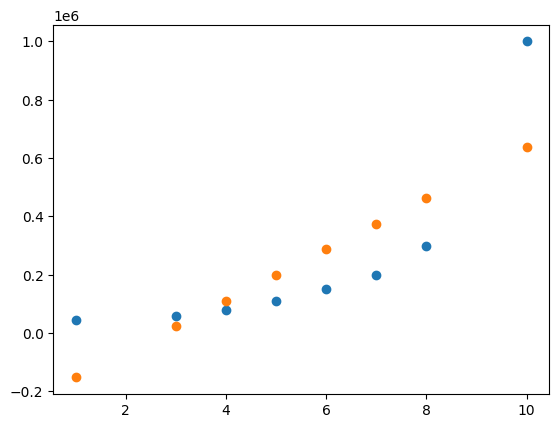

In [8]:
ypred_train=model.predict(xtrain)
plt.scatter(xtrain,ytrain)
plt.scatter(xtrain,ypred_train)

### Train Data

In [9]:
ypred_train=model.predict(xtrain)
score=r2_score(ytrain,ypred_train)
score

0.6366049276570868

### Polynomial Features

In [10]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=5)
updated_xtrain=poly.fit_transform(xtrain)
updated_xtest=poly.transform(xtest)

In [11]:
xtrain

,Level
5,6
0,1
7,8
2,3
9,10
4,5
3,4
6,7


In [12]:
updated_xtrain[:,1]

array([ 6.,  1.,  8.,  3., 10.,  5.,  4.,  7.])

In [13]:
model=LinearRegression()
model.fit(updated_xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0. , -6255.55,-10659.9 , 7504.89, -1323.88, 78.06]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.656e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[90764.27, 879.59, 22.72, 1.33, 0.05, 0. ]"


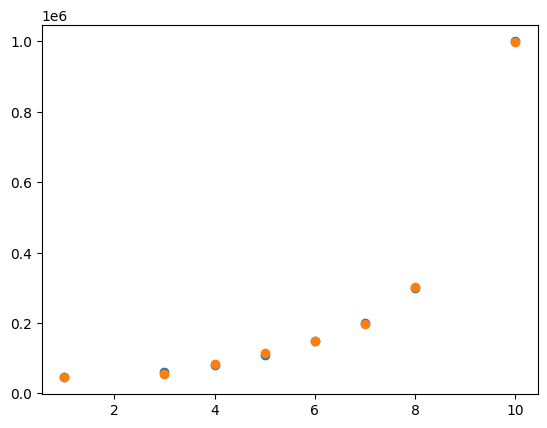

In [14]:
ypred_train=model.predict(updated_xtrain)
plt.scatter(updated_xtrain[:,1],ytrain)
plt.scatter(updated_xtrain[:,1],ypred_train)

## Train Score

R2 score

In [15]:
# train score
ypred_train=model.predict(updated_xtrain)
train_score=r2_score(ytrain,ypred_train)
print(f"Train Score : {train_score}")

Train Score : 0.9999341967549923


### Test Score

In [16]:
#test score
ypred_test=model.predict(updated_xtest)
test_score=r2_score(ytest,ypred_test)
print(f"Test Score : {test_score}")

Test Score : 0.9899442531814587


### Mean Absolute Error

In [17]:
Mae=mean_absolute_error(ytrain,ypred_train)
print(f"Mae : {Mae}")

Mae : 2139.525252904881


In [18]:
Mae=mean_absolute_error(ytest,ypred_test)
print(f"Mae : {Mae}")

Mae : 19156.19158573815


### Root Mean Squared Error

In [19]:
Rmse=root_mean_squared_error(ytrain,ypred_train)
print(f"Rmse : {Rmse}")

Rmse : 2405.95168382071


In [20]:
Rmse=root_mean_squared_error(ytest,ypred_test)
print(f"Rmse : {Rmse}")

Rmse : 22562.62800935762


degree=1

R2 score--> Train Score : 0.6366049276570868     Test Score : 0.8451346684575974

MAE-------> Train Score : 148836.2068965517      Test score : 82607.75862068967

RMSE------> Train Score : 178793.92696332143     Test Score : 88544.09867029045


degree=2

R2 Score-->Train Score : 0.9280776280497959      Test Score : 0.7666492889299912

MAE-------> Train Score : 70986.34468626347      Test score : 82607.7586206898

RMSE------> Train Score : 79541.76929650217      Test Score : 108689.37274600125

degree=3

R2 score-->Train Score : 0.9913280453724184      Test Score : 0.8762695647830073

MAE-------> Train Score : 23255.00382266974      Test score : 70635.24590164087

RMSE------> Train Score : 27619.877283630274     Test Score : 79144.50886107168

degree=4

R2 Score-->Train Score : 0.9995857211026753     Test Score : 0.9714666803843249

MAE-------> Train Score : 5445.142918578682      Test score : 35700.35460982748

RMSE------> Train Score : 6036.839812462632       Test Score : 38006.56924195543

degree=5

R2 Score-->Train Score : 0.9999341967549923     Test Score : 0.9899442531814587

MAE-------> Train Score : 2139.525252904881      Test score : 19156.19158573815

RMSE------> Train Score : 2405.95168382071       Test Score : 22562.62800935762

Model performs well at degree=5, with excellent accuracy on both train and test data

### BEST FIT